# 🎓 Student Performance Prediction Using Machine Learning

## Machine Learning Internship Project

**Intern:** Devi Bokkisim

### Objective
The objective of this project is to predict students' final exam scores based on academic performance, attendance, study habits, and extracurricular activities using Machine Learning techniques.

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib
- Git & GitHub

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Dataset Generation

In this step, a synthetic dataset containing **2500 student records** is generated using Python. The dataset includes academic, behavioral, and personal features that influence student performance. The generated dataset is saved as `student_performance.csv`.

In [4]:
import pandas as pd
import numpy as np

# Generate the same random values every time
np.random.seed(42)

# Number of students
n = 2500

# Student IDs
student_id = range(1, n + 1)

# Features
study_hours = np.random.randint(1, 11, n)
attendance = np.random.randint(60, 101, n)
assignments = np.random.randint(50, 101, n)
previous_marks = np.random.randint(40, 100, n)
sleep_hours = np.random.randint(4, 10, n)
internet_usage = np.random.randint(1, 8, n)
extra_classes = np.random.randint(0, 2, n)
sports_hours = np.random.randint(0, 4, n)
family_support = np.random.randint(1, 6, n)
screen_time = np.random.randint(1, 8, n)
motivation_level = np.random.randint(1, 6, n)

# Final Marks (Realistic Formula)
final_marks = (
    previous_marks * 0.35 +
    study_hours * 4 +
    attendance * 0.20 +
    assignments * 0.20 +
    sleep_hours * 1.5 +
    family_support * 2 +
    motivation_level * 3 -
    internet_usage * 1.2 -
    screen_time * 1.3 +
    extra_classes * 4 +
    sports_hours * 1.5 +
    np.random.normal(0, 5, n)
)

# Keep marks between 0 and 100
final_marks = np.clip(final_marks, 0, 100)

# Create DataFrame
data = pd.DataFrame({
    "Student_ID": student_id,
    "Study_Hours": study_hours,
    "Attendance": attendance,
    "Assignments": assignments,
    "Previous_Marks": previous_marks,
    "Sleep_Hours": sleep_hours,
    "Internet_Usage": internet_usage,
    "Extra_Classes": extra_classes,
    "Sports_Hours": sports_hours,
    "Family_Support": family_support,
    "Screen_Time": screen_time,
    "Motivation_Level": motivation_level,
    "Final_Marks": final_marks.round(2)
})

# Save dataset
data.to_csv("data/student_performance.csv", index=False)

print("Dataset created successfully!")
print(data.head())
print("\nShape:", data.shape)

OSError: Cannot save file into a non-existent directory: 'data'

In [5]:
import os             
os.getcwd()

'c:\\Users\\USER\\OneDrive\\Desktop\\Student_Performance_Prediction\\data\\src\\models\\images\\notebooks'

In [6]:
data.head()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Sleep_Hours,Internet_Usage,Extra_Classes,Sports_Hours,Family_Support,Screen_Time,Motivation_Level,Final_Marks
0,1,7,88,64,97,4,7,1,2,3,7,2,100.00
1,2,4,96,57,84,5,6,0,1,2,1,4,94.49
2,3,8,79,56,66,9,7,1,1,1,5,5,100.00
3,4,5,80,96,65,9,4,1,3,5,1,5,100.00
4,5,7,69,95,46,5,5,1,2,5,6,5,97.43


In [7]:
data.shape

(2500, 13)

## Data Preprocessing

In this step, the dataset is checked for missing values, duplicate records, data types, and summary statistics to ensure it is clean and ready for machine learning.

In [10]:


# Display dataset information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        2500 non-null   int64  
 1   Study_Hours       2500 non-null   int32  
 2   Attendance        2500 non-null   int32  
 3   Assignments       2500 non-null   int32  
 4   Previous_Marks    2500 non-null   int32  
 5   Sleep_Hours       2500 non-null   int32  
 6   Internet_Usage    2500 non-null   int32  
 7   Extra_Classes     2500 non-null   int32  
 8   Sports_Hours      2500 non-null   int32  
 9   Family_Support    2500 non-null   int32  
 10  Screen_Time       2500 non-null   int32  
 11  Motivation_Level  2500 non-null   int32  
 12  Final_Marks       2500 non-null   float64
dtypes: float64(1), int32(11), int64(1)
memory usage: 146.6 KB


In [11]:
data.describe()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Sleep_Hours,Internet_Usage,Extra_Classes,Sports_Hours,Family_Support,Screen_Time,Motivation_Level,Final_Marks
count,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,5.447600,80.152800,74.778000,69.126800,6.454400,4.032400,0.514000,1.496000,2.982000,3.995200,2.962800,91.068248
std,721.83216,2.889601,11.742564,14.531854,17.205427,1.710524,1.981141,0.499904,1.114307,1.409706,2.031164,1.399643,10.887534
min,1.00000,1.000000,60.000000,50.000000,40.000000,4.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,48.510000
25%,625.75000,3.000000,70.000000,63.000000,54.000000,5.000000,2.000000,0.000000,0.000000,2.000000,2.000000,2.000000,84.267500
50%,1250.50000,5.000000,80.000000,74.000000,69.000000,6.000000,4.000000,1.000000,2.000000,3.000000,4.000000,3.000000,96.125000
75%,1875.25000,8.000000,90.000000,87.250000,84.000000,8.000000,6.000000,1.000000,2.000000,4.000000,6.000000,4.000000,100.000000
max,2500.00000,10.000000,100.000000,100.000000,99.000000,9.000000,7.000000,1.000000,3.000000,5.000000,7.000000,5.000000,100.000000


In [12]:
data.isnull().sum()

Student_ID          0
Study_Hours         0
Attendance          0
Assignments         0
Previous_Marks      0
Sleep_Hours         0
Internet_Usage      0
Extra_Classes       0
Sports_Hours        0
Family_Support      0
Screen_Time         0
Motivation_Level    0
Final_Marks         0
dtype: int64

In [14]:
data.duplicated().sum()

np.int64(0)

In [15]:
data.describe()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Sleep_Hours,Internet_Usage,Extra_Classes,Sports_Hours,Family_Support,Screen_Time,Motivation_Level,Final_Marks
count,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,5.447600,80.152800,74.778000,69.126800,6.454400,4.032400,0.514000,1.496000,2.982000,3.995200,2.962800,91.068248
std,721.83216,2.889601,11.742564,14.531854,17.205427,1.710524,1.981141,0.499904,1.114307,1.409706,2.031164,1.399643,10.887534
min,1.00000,1.000000,60.000000,50.000000,40.000000,4.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,48.510000
25%,625.75000,3.000000,70.000000,63.000000,54.000000,5.000000,2.000000,0.000000,0.000000,2.000000,2.000000,2.000000,84.267500
50%,1250.50000,5.000000,80.000000,74.000000,69.000000,6.000000,4.000000,1.000000,2.000000,3.000000,4.000000,3.000000,96.125000
75%,1875.25000,8.000000,90.000000,87.250000,84.000000,8.000000,6.000000,1.000000,2.000000,4.000000,6.000000,4.000000,100.000000
max,2500.00000,10.000000,100.000000,100.000000,99.000000,9.000000,7.000000,1.000000,3.000000,5.000000,7.000000,5.000000,100.000000


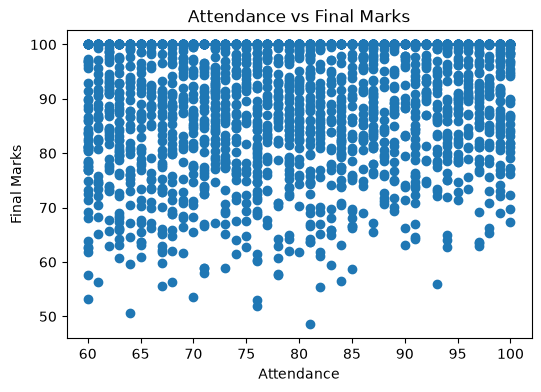

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(data["Attendance"], data["Final_Marks"])
plt.title("Attendance vs Final Marks")
plt.xlabel("Attendance")
plt.ylabel("Final Marks")
plt.show()

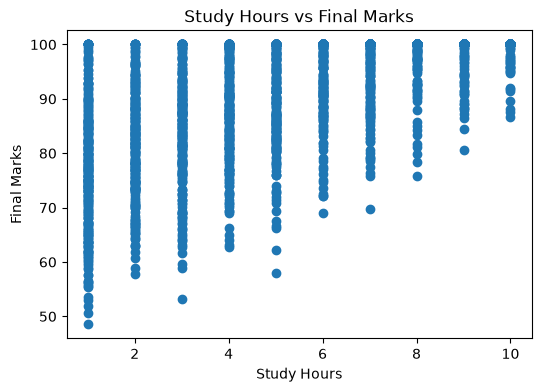

In [17]:
plt.figure(figsize=(6,4))
plt.scatter(data["Study_Hours"], data["Final_Marks"])
plt.title("Study Hours vs Final Marks")
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.show()

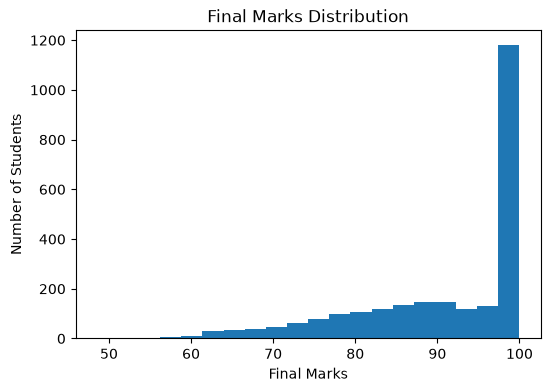

In [18]:
plt.figure(figsize=(6,4))
plt.hist(data["Final_Marks"], bins=20)
plt.title("Final Marks Distribution")
plt.xlabel("Final Marks")
plt.ylabel("Number of Students")
plt.show()

In [19]:
print(data.columns)

Index(['Student_ID', 'Study_Hours', 'Attendance', 'Assignments',
       'Previous_Marks', 'Sleep_Hours', 'Internet_Usage', 'Extra_Classes',
       'Sports_Hours', 'Family_Support', 'Screen_Time', 'Motivation_Level',
       'Final_Marks'],
      dtype='str')


In [20]:
## Data Preprocessing

The dataset is preprocessed to ensure data quality before training the machine learning model.

The following preprocessing steps are performed:
- Load the dataset
- Check dataset information
- Check missing values
- Remove duplicate records
- Save the cleaned dataset

SyntaxError: invalid syntax (3519916781.py, line 3)

In [21]:
from sklearn.model_selection import train_test_split

# Features and Target
X = data.drop(["Student_ID", "Final_Marks"], axis=1)
y = data["Final_Marks"]

# Convert categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2000, 11)
(500, 11)


In [22]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 3.4576889999999993
MSE : 22.796951126259998
RMSE: 4.774615285681141
R2 Score: 0.8032121213474265


In [24]:
sample = X_test.iloc[[0]]
prediction = model.predict(sample)

print("Predicted Final Marks:", round(prediction[0], 2))
print("Actual Final Marks:", y_test.iloc[0])

Predicted Final Marks: 91.07
Actual Final Marks: 84.13


In [26]:
import joblib

joblib.dump(model, "student_performance_model.pkl")
print("Model saved successfully!")

print("Model saved successfully!")

Model saved successfully!
Model saved successfully!


In [27]:
loaded_model = joblib.load("models/student_performance_model.pkl")

prediction = loaded_model.predict(X_test.iloc[[0]])

print("Predicted Final Marks:", prediction[0])

FileNotFoundError: [Errno 2] No such file or directory: 'models/student_performance_model.pkl'

In [28]:
print(X.columns)

Index(['Study_Hours', 'Attendance', 'Assignments', 'Previous_Marks',
       'Sleep_Hours', 'Internet_Usage', 'Extra_Classes', 'Sports_Hours',
       'Family_Support', 'Screen_Time', 'Motivation_Level'],
      dtype='str')


In [29]:
# Interactive Prediction System

study_hours = float(input("Study Hours: "))
attendance = float(input("Attendance (%): "))
assignments = float(input("Assignments (%): "))
previous_marks = float(input("Previous Marks: "))
sleep_hours = float(input("Sleep Hours: "))
internet_usage = float(input("Internet Usage (hours/day): "))
extra_classes = int(input("Extra Classes (0=No, 1=Yes): "))
sports_hours = float(input("Sports Hours: "))
family_support = int(input("Family Support (1-5): "))
screen_time = float(input("Screen Time (hours/day): "))
motivation_level = int(input("Motivation Level (1-5): "))

prediction = model.predict([[study_hours, attendance, assignments,
                             previous_marks, sleep_hours,
                             internet_usage, extra_classes,
                             sports_hours, family_support,
                             screen_time, motivation_level]])

print("\nPredicted Final Marks:", round(prediction[0], 2))


Predicted Final Marks: 99.97


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
